# Psychological State Detection using Machine Learning

## Objective
The goal of this project is to predict a person's psychological state using physiological, behavioral, and demographic signals.

This project uses:
- HRV
- GSR
- EEG
- Heart rate
- Oxygen level
- Cognitive load
- Focus duration
- Demographic details

We will build a professional machine learning pipeline:
1. Data understanding
2. Cleaning
3. Exploratory analysis
4. Feature engineering
5. Model building
6. Hyperparameter tuning
7. Model evaluation
8. Model saving
9. Streamlit deployment

##  Import Required Libraries
In this step, we import all Python libraries needed for data analysis, visualization, preprocessing, and machine learning.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import joblib

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt

## Load Dataset
Now we load the Kaggle dataset from our project folder and inspect the first few rows.

In [38]:
df = pd.read_csv("../data/psychological_state_dataset.csv")
df.head()

,ID,Time,HRV (ms),GSR (μS),EEG Power Bands,Blood Pressure (mmHg),Oxygen Saturation (%),Heart Rate (BPM),Ambient Noise (dB),Cognitive Load,Mood State,Psychological State,Respiration Rate (BPM),Skin Temp (°C),Focus Duration (s),Task Type,Age,Gender,Educational Level,Study Major
0,1,2024-01-01 00:00:00,33.039739,1.031806,"[0.7583653347946298, 1.423247998317594, 0.6157...",114/79,98.433312,98,56.863054,Low,Anxious,Stressed,21,34.566484,27,Exam,22,Female,Postgraduate,Engineering
1,2,2024-01-01 00:00:01,49.914651,1.340983,"[0.5520419333516282, 1.858065835142619, 0.3766...",113/86,98.944505,70,45.343430,Low,Neutral,Stressed,21,35.358593,282,Assignment,23,Male,Undergraduate,Arts
2,3,2024-01-01 00:00:02,67.894401,1.006014,"[1.0261365005886114, 1.3504934190994182, 2.308...",124/74,95.990753,91,50.029264,High,Sad,Relaxed,17,34.359495,50,Group Discussion,18,Female,Postgraduate,Arts
3,4,2024-01-01 00:00:03,34.705373,0.849270,"[1.6075723109471591, 1.6619672129812242, 0.344...",120/73,98.173643,95,60.802104,Low,Neutral,Anxious,12,34.802638,223,Exam,28,Female,High School,Engineering
4,5,2024-01-01 00:00:04,52.896549,0.879084,"[1.055003922514022, 0.7643319894343756, 1.0745...",111/80,96.225051,65,40.696384,High,Anxious,Stressed,14,35.869862,201,Group Discussion,24,Female,High School,Engineering


## Understand Dataset Shape and Features
This helps us understand:
- number of rows
- number of columns
- feature names
- missing values
- data types

In [39]:
print("Shape:", df.shape)
df.info()

Shape: (1000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1000 non-null   int64  
 1   Time                    1000 non-null   str    
 2   HRV (ms)                1000 non-null   float64
 3   GSR (μS)                1000 non-null   float64
 4   EEG Power Bands         1000 non-null   str    
 5   Blood Pressure (mmHg)   1000 non-null   str    
 6   Oxygen Saturation (%)   1000 non-null   float64
 7   Heart Rate (BPM)        1000 non-null   int64  
 8   Ambient Noise (dB)      1000 non-null   float64
 9   Cognitive Load          1000 non-null   str    
 10  Mood State              1000 non-null   str    
 11  Psychological State     1000 non-null   str    
 12  Respiration Rate (BPM)  1000 non-null   int64  
 13  Skin Temp (°C)          1000 non-null   float64
 14  Focus Duration (s)      1000 non-n

## Exploratory Data Analysis
Here we study the distribution of psychological states and understand important patterns in the data.

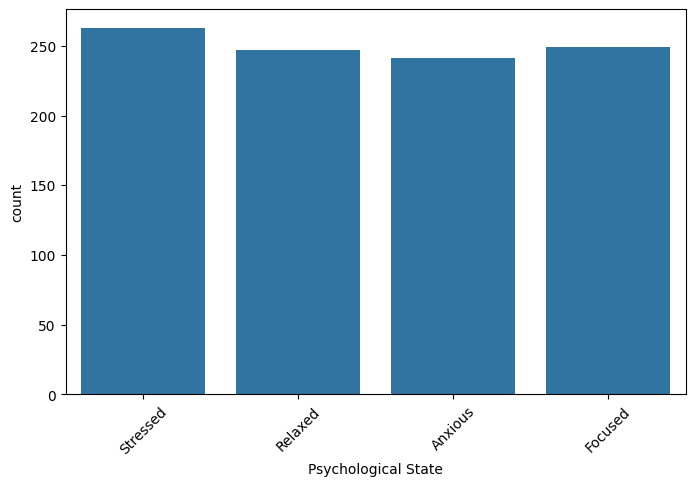

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='Psychological State', data=df)
plt.xticks(rotation=45)
plt.show()

## Missing Value Check
Before building ML models, we must check whether any data is missing.

In [41]:
df.isnull().sum()

ID                        0
Time                      0
HRV (ms)                  0
GSR (μS)                  0
EEG Power Bands           0
Blood Pressure (mmHg)     0
Oxygen Saturation (%)     0
Heart Rate (BPM)          0
Ambient Noise (dB)        0
Cognitive Load            0
Mood State                0
Psychological State       0
Respiration Rate (BPM)    0
Skin Temp (°C)            0
Focus Duration (s)        0
Task Type                 0
Age                       0
Gender                    0
Educational Level         0
Study Major               0
dtype: int64

## Feature Selection and Target Separation
We separate:
- input features → X
- target column → y

In [42]:
X = df.drop(columns=['Psychological State', 'ID', 'Time'])
y = df['Psychological State']

In [43]:
X.head()             # works as before
pd.Series(y).head()  # wrap y in a Series to use head()

0    Stressed
1    Stressed
2     Relaxed
3     Anxious
4    Stressed
Name: Psychological State, dtype: str

## Encode Target Labels
Machine learning models work with numbers, so we convert text labels into numeric form.

In [44]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [45]:
y[:10]  # first 10 encoded labels

array([3, 3, 2, 0, 3, 3, 0, 1, 1, 0])

## Data Preprocessing Pipeline
This professional preprocessing pipeline handles:
- missing values
- categorical encoding
- scaling

In [46]:
categorical_cols = X.select_dtypes(include=['object', 'string']).columns
categorical_cols  # This will display the column names in Jupyter

Index(['EEG Power Bands', 'Blood Pressure (mmHg)', 'Cognitive Load',
       'Mood State', 'Task Type', 'Gender', 'Educational Level',
       'Study Major'],
      dtype='str')

## Train Test Split
We divide the dataset into:
- training data → model learning
- testing data → final evaluation

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

((800, 17), (200, 17), (800,), (200,))

## Build Advanced Professional ML Pipeline
We use Random Forest because it works very well on mixed numerical and categorical data.

In [48]:
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Model Prediction
Now the trained model predicts psychological state on unseen test data.

In [49]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[2 3 1 3 0 3 2 3 3 3]


## Model Evaluation
We measure:
- accuracy
- precision
- recall
- F1-score
- confusion matrix

In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.285
              precision    recall  f1-score   support

           0       0.35      0.16      0.22        50
           1       0.25      0.19      0.22        53
           2       0.36      0.35      0.36        51
           3       0.24      0.46      0.32        46

    accuracy                           0.28       200
   macro avg       0.30      0.29      0.28       200
weighted avg       0.30      0.28      0.28       200



## Confusion Matrix Visualization
This helps us understand where the model predicts correctly and where it makes mistakes.

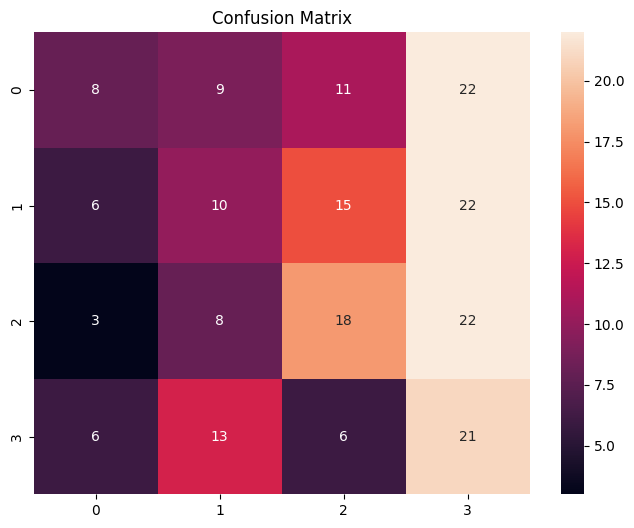

In [51]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Feature Importance Analysis
This is an advanced professional step that explains which physiological signals most influence psychological state.

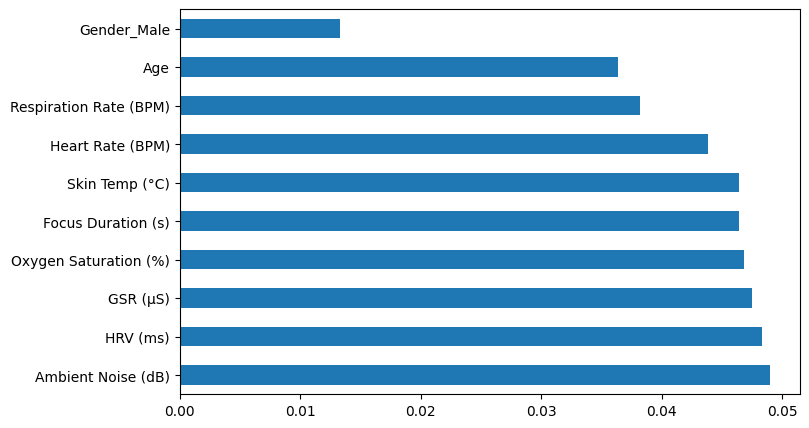

In [52]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,5))
plt.show()

## Save Trained Model
We save the trained model so it can be used inside the Streamlit app.

In [53]:
joblib.dump(model, "../models/best_model.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']

## Compare Multiple Machine Learning Models
Instead of using only one model, we compare multiple algorithms.

This helps us select the best-performing model scientifically.

Training Logistic Regression...
Logistic Regression Accuracy: 0.2350

Training Random Forest...
Random Forest Accuracy: 0.2450

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.2250



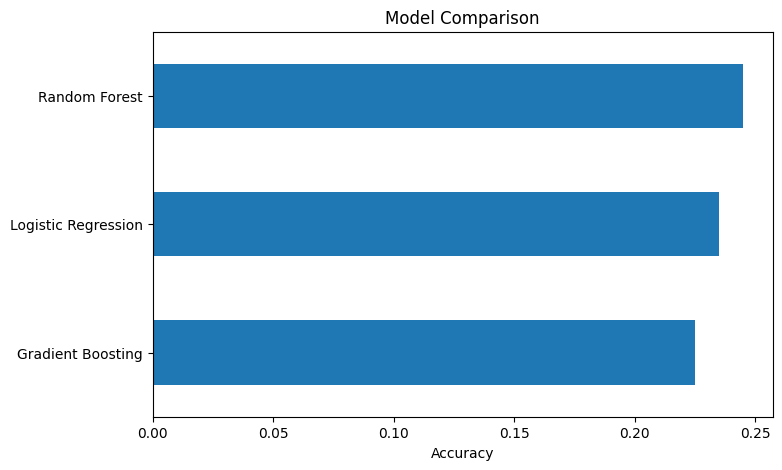

In [54]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv("../data/psychological_state_dataset.csv")

# Prepare features and target
X = df.drop(columns=['Psychological State', 'ID', 'Time'])
y = df['Psychological State']

# Encode target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train and evaluate
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}\n")

# Plot results
pd.Series(results).sort_values().plot(kind="barh", figsize=(8,5))
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.show()

## Visual Comparison of Model Accuracy
This graph clearly shows which model performs best.

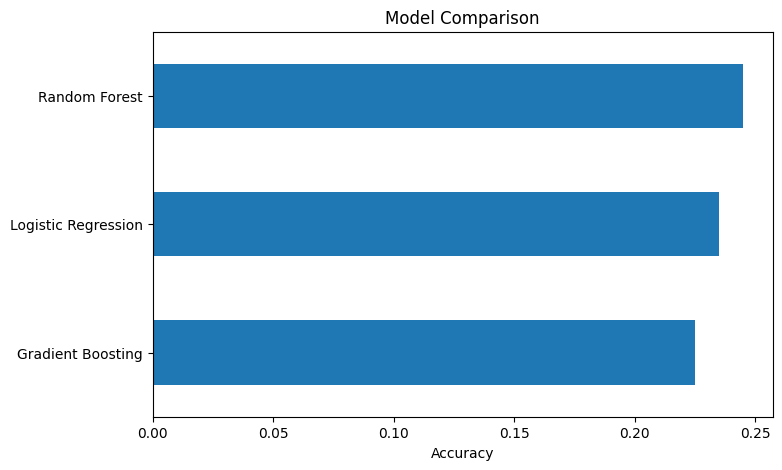

In [55]:
pd.Series(results).sort_values().plot(kind="barh", figsize=(8,5))
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.show()

## Cross Validation for Reliable Performance
Cross-validation checks whether the model performs consistently on different data splits.

This is an important professional machine learning practice.

In [56]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.21  0.285 0.24  0.295 0.24 ]
Mean CV Accuracy: 0.254


## Hyperparameter Tuning using GridSearchCV
Now we improve the Random Forest model by finding the best parameter combination.

This is a very important advanced ML step.

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.24998357316512254


## Use the Best Tuned Model
Now we use the best model selected by GridSearchCV.

In [58]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned Model Accuracy: 0.23
              precision    recall  f1-score   support

           0       0.32      0.19      0.24        48
           1       0.25      0.26      0.25        50
           2       0.06      0.04      0.05        49
           3       0.26      0.42      0.32        53

    accuracy                           0.23       200
   macro avg       0.22      0.23      0.21       200
weighted avg       0.22      0.23      0.22       200



##  Evaluate Tuned Model with Confusion Matrix
This helps us analyze class-level prediction quality.

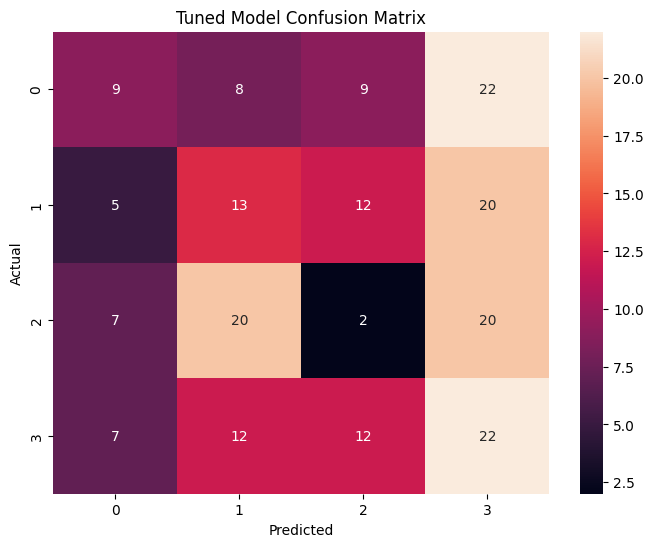

In [62]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Tuned Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##  Top 15 Most Important Features
This shows which physiological signals most strongly affect psychological state prediction.

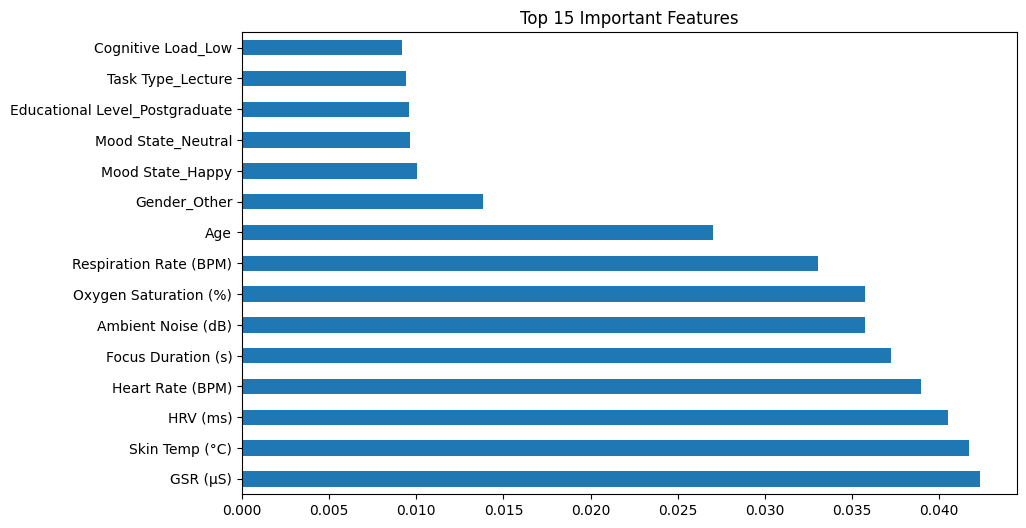

In [63]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15).plot(kind="barh", figsize=(10,6))
plt.title("Top 15 Important Features")
plt.show()

## Business & Research Insight
From feature importance, we can understand which physiological factors most influence psychological state.

This can be useful in:
- mental health monitoring
- wearable devices
- smart healthcare
- stress detection systems
- workplace productivity analysis

## Explain Model Decisions using SHAP
SHAP helps explain why the model predicted a particular psychological state.

This is highly professional and commonly used in AI explainability projects.

In [61]:
import sys
!"{sys.executable}" -m pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\Janu Dhanya\OneDrive\Desktop\PythonProject\.venv\Scripts\python.exe -m pip install --upgrade pip


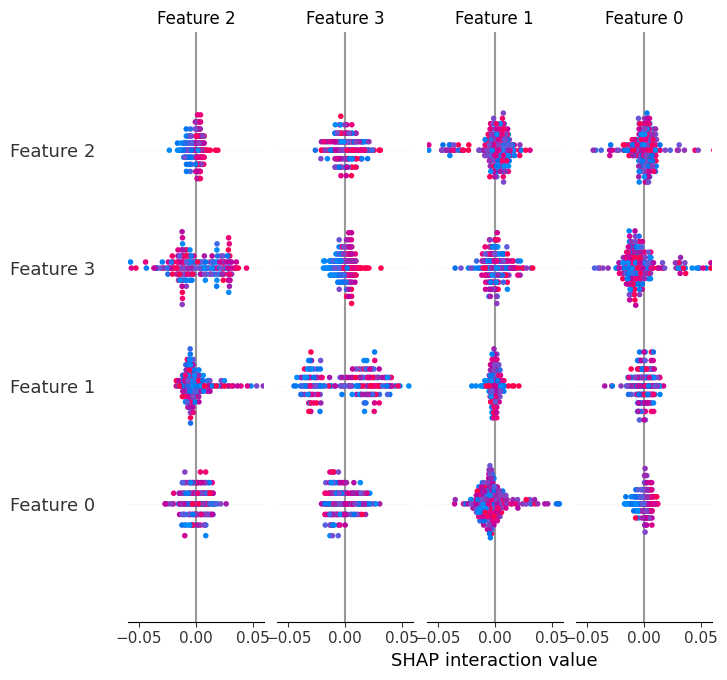

In [65]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

##  Save Final Tuned Model
We save the best tuned model for Streamlit deployment.

In [66]:
joblib.dump(best_model, "../models/final_tuned_model.pkl")

['../models/final_tuned_model.pkl']